In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# 3. Gün ürettiğimiz veriyi Customer ID indeks olacak şekilde okuyoruz
df_rfm = pd.read_csv('../data/processed/rfm_segmented.csv', index_col='Customer ID')
print(f"Toplam Müşteri Sayısı: {df_rfm.shape[0]}")
df_rfm.head()

Toplam Müşteri Sayısı: 4312


,recency,frequency,monetary,tenure,avg_order_value,recency_score,frequency_score,monetary_score,RF_SCORE,segment
Customer ID,,,,,,,,,,
12346,166,11,372.86,362,33.90,2,5,2,25,cant_loose
12347,4,2,1323.32,41,661.66,5,2,4,52,potential_loyalists
12348,75,1,222.16,75,222.16,2,1,1,21,hibernating
12349,44,3,2671.14,226,890.38,3,3,5,33,need_attention
12351,12,1,300.93,12,300.93,5,1,2,51,new_customers


In [3]:
# Sadece sayısal RFM özelliklerini seçiyoruz
features = ['recency', 'frequency', 'monetary']
df_features = df_rfm[features].copy()

# 1. Aşırı sağa çarpıklığı düzeltmek için Log Dönüşümü (np.log1p)
df_log = np.log1p(df_features)

# 2. Standartlaştırma (Z-score normalizasyonu)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df_log)

# Ölçeklenmiş veriyi DataFrame haline getirelim
df_scaled = pd.DataFrame(rfm_scaled, index=df_rfm.index, columns=features)
df_scaled.head()

,recency,frequency,monetary
Customer ID,,,
12346,0.98,1.61,-0.54
12347,-1.85,-0.39,0.45
12348,0.34,-0.98,-0.94
12349,-0.08,0.02,1.00
12351,-1.08,-0.98,-0.71


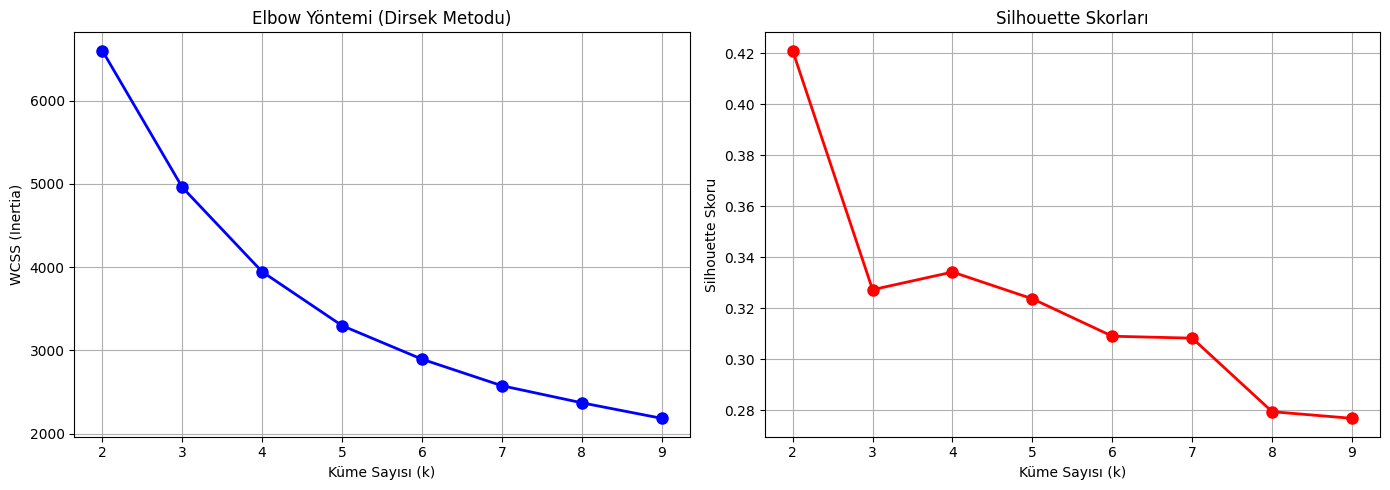

k = 2 -> Silhouette Skoru: 0.4209
k = 3 -> Silhouette Skoru: 0.3272
k = 4 -> Silhouette Skoru: 0.3342
k = 5 -> Silhouette Skoru: 0.3237
k = 6 -> Silhouette Skoru: 0.3090
k = 7 -> Silhouette Skoru: 0.3082
k = 8 -> Silhouette Skoru: 0.2794
k = 9 -> Silhouette Skoru: 0.2768


In [4]:
wcss = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Grafiklerle görselleştirelim
fig, ax1 = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Grafiği
ax1[0].plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
ax1[0].set_title('Elbow Yöntemi (Dirsek Metodu)')
ax1[0].set_xlabel('Küme Sayısı (k)')
ax1[0].set_ylabel('WCSS (Inertia)')
ax1[0].grid(True)

# Silhouette Skoru Grafiği
ax1[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax1[1].set_title('Silhouette Skorları')
ax1[1].set_xlabel('Küme Sayısı (k)')
ax1[1].set_ylabel('Silhouette Skoru')
ax1[1].grid(True)

plt.tight_layout()
plt.show()

for k, score in zip(k_range, silhouette_scores):
    print(f"k = {k} -> Silhouette Skoru: {score:.4f}")

In [5]:
# En yüksek Silhouette skoru ve dengeli ayrışma sunan k değerini (örn: k=3 veya 4) seçiyoruz
chosen_k = 4

kmeans_model = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
df_rfm['kmeans_cluster'] = kmeans_model.fit_predict(df_scaled)

df_rfm.head()

,recency,frequency,monetary,tenure,avg_order_value,recency_score,frequency_score,monetary_score,RF_SCORE,segment,kmeans_cluster
Customer ID,,,,,,,,,,,
12346,166,11,372.86,362,33.90,2,5,2,25,cant_loose,0
12347,4,2,1323.32,41,661.66,5,2,4,52,potential_loyalists,3
12348,75,1,222.16,75,222.16,2,1,1,21,hibernating,1
12349,44,3,2671.14,226,890.38,3,3,5,33,need_attention,0
12351,12,1,300.93,12,300.93,5,1,2,51,new_customers,3


In [6]:
cluster_summary = df_rfm.groupby('kmeans_cluster').agg({
    'recency': ['mean', 'median'],
    'frequency': ['mean', 'median'],
    'monetary': ['mean', 'median', 'count']
})

cluster_summary.columns = ['recency_mean', 'recency_median', 'frequency_mean', 'frequency_median', 'monetary_mean', 'monetary_median', 'customer_count']
cluster_summary['customer_share_%'] = (cluster_summary['customer_count'] / len(df_rfm)) * 100

cluster_summary.sort_values(by='monetary_mean', ascending=False)

,recency_mean,recency_median,frequency_mean,frequency_median,monetary_mean,monetary_median,customer_count,customer_share_%
kmeans_cluster,,,,,,,,
2,15.00,11.00,13.55,9.00,7400.13,3429.00,780,18.09
0,83.61,66.00,4.14,4.00,1784.09,1371.26,1168,27.09
3,24.46,22.00,2.07,2.00,566.82,488.00,974,22.59
1,190.12,187.00,1.30,1.00,305.04,257.64,1390,32.24


In [7]:
import os

output_path = os.path.abspath("../data/processed/kmeans_clustered_customers.csv")
df_rfm.to_csv(output_path)
print(f"K-Means ile kümelenmiş veri başarıyla kaydedildi: {output_path}")

K-Means ile kümelenmiş veri başarıyla kaydedildi: C:\Users\USER\ecommerce-intelligence\data\processed\kmeans_clustered_customers.csv
